In [75]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2023-01-01")

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600
2018-01-04,40.484341,40.587289,40.262067,40.369693,89738400
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200


In [76]:
data["Returns"] = data["Close"].pct_change()
data[["Close", "Returns"]].head()

Price,Close,Returns
Ticker,AAPL,
Date,,
2018-01-02,40.304176,NaN
2018-01-03,40.297157,-0.000174
2018-01-04,40.484341,0.004645
2018-01-05,40.945255,0.011385
2018-01-08,40.793179,-0.003714


In [77]:
data["Volatility"] = data["Returns"].rolling(30).std()

data[["Returns", "Volatility"]].tail()

Price,Returns,Volatility
Ticker,,
Date,,
2022-12-23,-0.002798,0.019061
2022-12-27,-0.013878,0.018657
2022-12-28,-0.030685,0.019244
2022-12-29,0.028324,0.019969
2022-12-30,0.002469,0.019998


In [78]:
data["Cumulative_Return"] = (1 + data["Returns"]).cumprod()

data[["Cumulative_Return"]].tail()


Price,Cumulative_Return
Ticker,
Date,
2022-12-23,3.219985
2022-12-27,3.175297
2022-12-28,3.077863
2022-12-29,3.165041
2022-12-30,3.172855


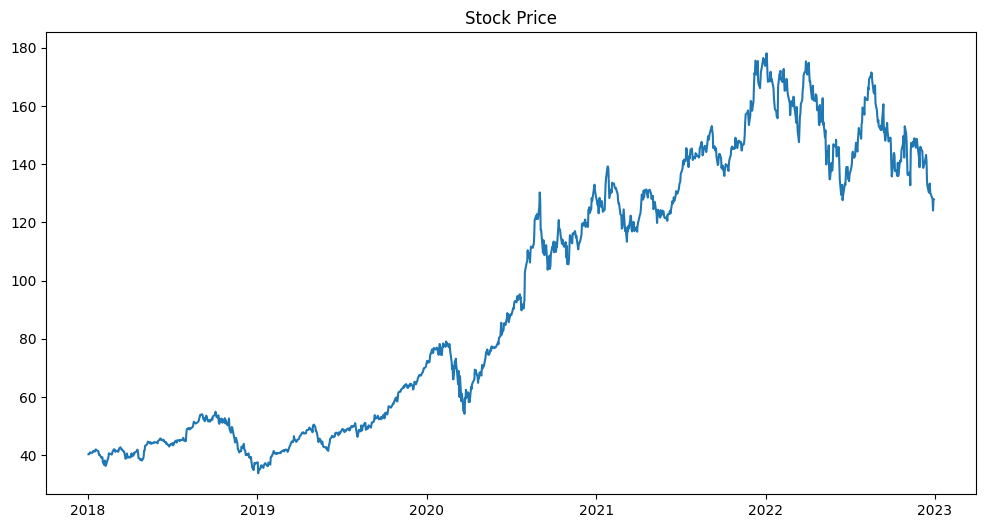

In [79]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"])
plt.title("Stock Price")
plt.show()


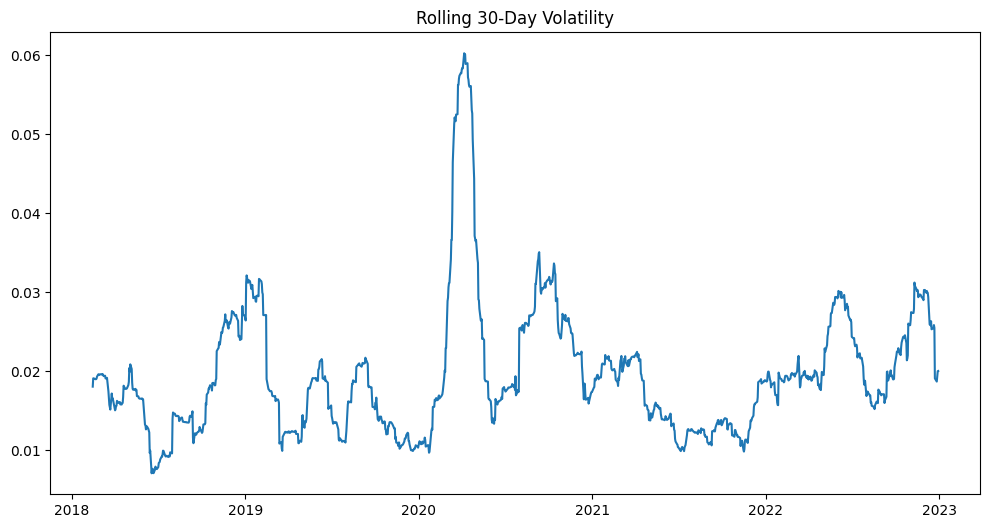

In [80]:
plt.figure(figsize=(12,6))
plt.plot(data["Volatility"])
plt.title("Rolling 30-Day Volatility")
plt.show()


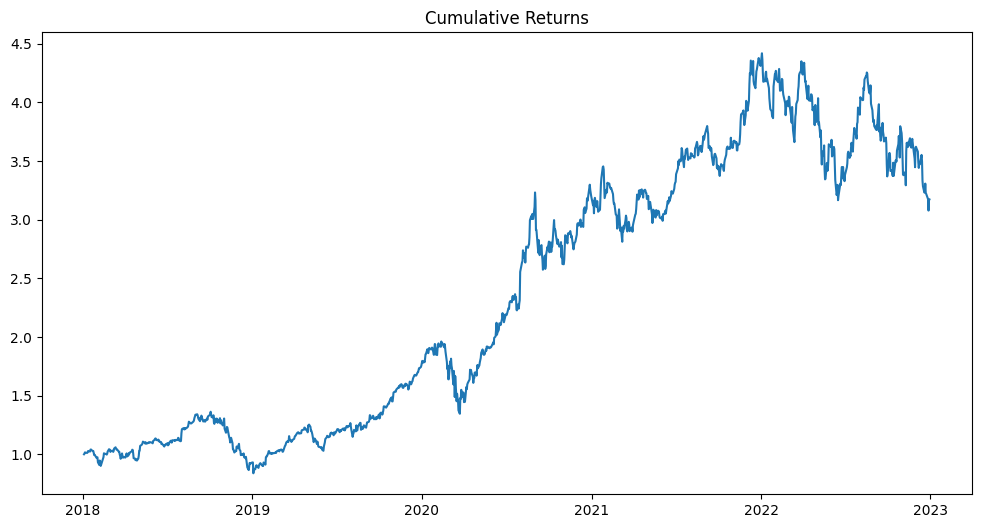

In [81]:
plt.figure(figsize=(12,6))
plt.plot(data["Cumulative_Return"])
plt.title("Cumulative Returns")
plt.show()


In [82]:
data["Volatility"].max()

np.float64(0.06022435570334966)

In [83]:
data["Volatility"].idxmax()

Timestamp('2020-04-06 00:00:00')

In [84]:
prices = {"AAPL": 150, "MSFT": 300}
shares = {"AAPL": 10, "MSFT": 5}

total_value = 0

for stock in prices:
    total_value += prices[stock] * shares[stock]

print(total_value) # 3000

3000


In [85]:
initial_investment = 1000
rate = 0.07
years = 5

value = initial_investment

for year in range(years):
    value *= (1 + rate)

print(value) # 1402.55

1402.5517307000005


In [86]:
cash_flows = [100, 200, 150, 300]
total = 0

for cash in cash_flows:
    total += cash

print(total) # 750

750


In [87]:
def present_value(cash_flow, rate, time):
    return cash_flow / (1 + rate) ** time

pv = present_value(1000, 0.08, 3)
print(pv) # 793.83

793.8322410201696


In [88]:
def portfolio_return(weights, returns):
    total = 0
    for i in range(len(weights)):
        total += weights[i] * returns[i]
    return total

weights = [0.5, 0.5]
returns = [0.02, 0.04]

print(portfolio_return(weights, returns)) # 0.03


0.03


In [89]:
def risk_check(volatility, threshold=0.3):
    if volatility > threshold:
        return "High Risk"
    else:
        return "Acceptable Risk"
data["Risk_Level"] = data["Volatility"].apply(risk_check)
data[["Volatility", "Risk_Level"]].tail()

print(data[["Volatility", "Risk_Level"]].tail())

Price      Volatility       Risk_Level
Ticker                                
Date                                  
2022-12-23   0.019061  Acceptable Risk
2022-12-27   0.018657  Acceptable Risk
2022-12-28   0.019244  Acceptable Risk
2022-12-29   0.019969  Acceptable Risk
2022-12-30   0.019998  Acceptable Risk


In [90]:
ma_20 = moving_average(prices, 20)
ma_50 = moving_average(prices, 50)


NameError: name 'moving_average' is not defined

In [ ]:
def risk_check(volatility, threshold=0.3):
    if volatility > threshold:
        return "High Risk"
    else:
        return "Acceptable Risk"
data["Risk_Level"] = data["Volatility"].apply(risk_check)
data[["Volatility", "Risk_Level"]].tail()

Price,Volatility,Risk_Level
Ticker,,
Date,,
2022-12-23,0.019061,Acceptable Risk
2022-12-27,0.018657,Acceptable Risk
2022-12-28,0.019244,Acceptable Risk
2022-12-29,0.019969,Acceptable Risk
2022-12-30,0.019998,Acceptable Risk


In [ ]:
import math

def monthly_payment(principal, annual_rate, years):
    if principal <= 0:
        raise ValueError("Principal must be positive")
    
    if annual_rate < 0:
        raise ValueError("Interest rate cannot be negative")
    
    if years <= 0:
        raise ValueError("Years must be positive")

    monthly_rate = annual_rate / 12
    total_payments = years * 12

    if monthly_rate == 0:
        return principal / total_payments

    numerator = principal * (monthly_rate * (1 + monthly_rate) ** total_payments)
    denominator = ((1 + monthly_rate) ** total_payments) - 1

    return numerator / denominator

def total_payment(monthly_payment, years):
    return monthly_payment * years * 12

def total_interest(total_paid, principal):
    return total_paid - principal

print(monthly_payment(100000, 0.05, 30)) # 536.82
print(total_payment(536.82, 30)) # 193255.20


In [ ]:
def amortization_schedule(principal, annual_rate, years):
    schedule = []
    monthly_rate = annual_rate / 12
    total_payments = years * 12
    payment = monthly_payment(principal, annual_rate, years)

    balance = principal

    for month in range(1, total_payments + 1):
        interest = balance * monthly_rate
        principal_paid = payment - interest
        balance -= principal_paid

        schedule.append({
            "month": month,
            "payment": payment,
            "principal_paid": principal_paid,
            "interest_paid": interest,
            "remaining_balance": max(balance, 0)
        })

    return schedule


In [91]:
import numpy as np

prices = np.array([100, 102, 101, 105, 110])
returns = (prices[1:] / prices[:-1]) - 1
print(returns)

[ 0.02       -0.00980392  0.03960396  0.04761905]


In [ ]:
mean_return = np.mean(returns)
print(mean_return) # 0.01

In [ ]:
volatility = np.std(returns)
print(volatility) # 0.035

In [ ]:
annual_vol = volatility * np.sqrt(252)
print(annual_vol) # 0.55

In [ ]:
weights = np.array([0.4, 0.3, 0.3])
asset_returns = np.array([0.05, 0.02, 0.08])

portfolio_return = np.dot(weights, asset_returns)
print(portfolio_return) # 0.05

In [93]:
asset1 = np.array([0.01, 0.02, -0.01, 0.03])
asset2 = np.array([0.02, 0.01, 0.00, 0.04])

returns_matrix = np.vstack([asset1, asset2])

cov_matrix = np.cov(returns_matrix)
print(cov_matrix)

[[0.00029167 0.00024167]
 [0.00024167 0.00029167]]


In [ ]:
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_volatility = np.sqrt(portfolio_variance)
print(portfolio_volatility) # 0.15

In [95]:
import numpy as np

S0 = 100
mu = 0.07
sigma = 0.2
T = 1
n_sim = 10000

random_shocks = np.random.normal(0, 1, n_sim)

future_prices = S0 * np.exp(
    (mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * random_shocks
)
print(future_prices[:10])

[124.57535004 105.54118925  93.48876432 200.11883548 138.80558472
 120.90432189 114.37203214 124.05837201 133.7383465  144.93227809]


In [ ]:
weights = np.array([0.5, 0.3, 0.2])
returns_matrix = np.array([
    [0.01, 0.02, 0.015],
    [-0.01, 0.01, 0.005],
    [0.02, -0.01, 0.02]
])
portfolio_returns = returns_matrix @ weights
print(portfolio_returns) # [0.015, 0.002, 0.01]

In [ ]:
returns = []
for i in range(1, len(prices)):
    returns.append((prices[i] / prices[i-1]) - 1)
print(returns)

[np.float64(0.020000000000000018), np.float64(-0.009803921568627416), np.float64(0.03960396039603964), np.float64(0.04761904761904767)]


In [104]:
import numpy as np

def portfolio_metrics(weights, returns_matrix):
    mean_returns = np.mean(returns_matrix, axis=0)
    cov_matrix = np.cov(returns_matrix.T)

    portfolio_return = np.dot(weights, mean_returns)
    portfolio_variance = weights.T @ cov_matrix @ weights
    portfolio_vol = np.sqrt(portfolio_variance)

    return {
        "expected_return": portfolio_return,
        "volatility": portfolio_vol
    }

weights = np.array([0.5, 0.3, 0.2])
returns_matrix = np.array([
    [0.01, 0.02, 0.015],
        [-0.01, 0.01, 0.005],
        [0.02, -0.01, 0.02]
])
metrics = portfolio_metrics(weights, returns_matrix)
print(metrics)


{'expected_return': np.float64(0.008), 'volatility': np.float64(0.007937253933193772)}


In [105]:
prices = [100, 105, 110]

returns = []
for i in range(1, len(prices)):
    r = (prices[i] - prices[i-1]) / prices[i-1]
    returns.append(r)

print(returns)


[0.05, 0.047619047619047616]


In [ ]:
import numpy as np

prices = np.array([100, 101.5, 102.3, 99.8])
returns = (prices[1:] - prices[:-1]) / prices[:-1]
print(returns) # [0.015, 0.0078, -0.0488]

In [106]:
weights = np.array([0.4, 0.3, 0.3])
returns = np.array([0.05, 0.02, 0.03])

portfolio_return = np.dot(weights, returns)
print(portfolio_return)

0.035


In [107]:
import numpy as np

prices = np.array([100, 105, 103, 108])

log_returns = np.log(prices[1:] / prices[:-1])
print(log_returns)

[ 0.04879016 -0.01923136  0.04740224]


In [109]:
weights = np.array([0.4, 0.3, 0.3])
asset_returns = np.array([0.05, 0.02, 0.03])

portfolio_return = weights @ asset_returns
print(portfolio_return)

0.035


In [110]:
cov_matrix = np.array([
    [0.1, 0.02, 0.03],
    [0.02, 0.08, 0.01],
    [0.03, 0.01, 0.09]
])

portfolio_variance = weights @ cov_matrix @ weights
print(portfolio_variance)

0.04510000000000001


In [112]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

A * B

array([[ 5, 12],
       [21, 32]])

In [113]:
A @ B

array([[19, 22],
       [43, 50]])

In [114]:
np.dot(A, B)

array([[19, 22],
       [43, 50]])

NameError: name 'A' is not defined

In [115]:
weights = np.array([0.5, 0.3, 0.2])
returns = np.array([0.10, 0.05, 0.08])

portfolio_return = weights @ returns
print(portfolio_return)


0.081


In [116]:
cov_matrix = np.array([
    [0.10, 0.02, 0.04],
    [0.02, 0.08, 0.01],
    [0.04, 0.01, 0.09]
])

portfolio_variance = weights @ cov_matrix @ weights
print(portfolio_variance)


0.051000000000000004


In [117]:
weights.T

array([0.5, 0.3, 0.2])

In [118]:
W = weights.reshape(-1, 1)
W.T


array([[0.5, 0.3, 0.2]])

In [120]:
returns_matrix = np.array([
    [0.01, 0.02, -0.01],
    [0.03, -0.01, 0.02],
    [-0.02, 0.01, 0.01]
])
cov_matrix = np.cov(returns_matrix.T)
print(cov_matrix)

[[ 6.33333333e-04 -2.16666667e-04  8.33333333e-05]
 [-2.16666667e-04  2.33333333e-04 -2.16666667e-04]
 [ 8.33333333e-05 -2.16666667e-04  2.33333333e-04]]


In [123]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [124]:
import numpy as np
import time

prices = np.random.random(1_000_000)

start = time.time()

returns = []
for i in range(1, len(prices)):
    r = (prices[i] - prices[i-1]) / prices[i-1]
    returns.append(r)

end = time.time()
print("Loop time:", end - start)


Loop time: 0.4261198043823242


In [125]:
start = time.time()

returns = [(prices[i] - prices[i-1]) / prices[i-1]
           for i in range(1, len(prices))]

end = time.time()
print("List comprehension time:", end - start)


List comprehension time: 0.30361318588256836


In [ ]:
start = time.time()

returns = (prices[1:] - prices[:-1]) / prices[:-1]

end = time.time()
print("Vectorized time:", end - start)


Vectorized time: 0.018047332763671875


In [127]:
portfolio_variance = weights @ cov_matrix @ weights

In [137]:
import numpy as np

np.random.seed(42)

# 3 assets, 1000 days
prices = 100 * np.cumprod(1 + np.random.normal(0.0005, 0.01, (1000, 3)), axis=0)
returns = np.diff(prices, axis=0) / prices[:-1]
def portfolio_metrics(weights, returns_matrix):
    mean_returns = np.mean(returns_matrix, axis=0)
    cov_matrix = np.cov(returns_matrix.T)

    portfolio_return = np.dot(weights, mean_returns)
    portfolio_variance = weights.T @ cov_matrix @ weights
    portfolio_vol = np.sqrt(portfolio_variance)

    return {    "expected_return": portfolio_return,
        "volatility": portfolio_vol
    }   
weights = np.array([0.5, 0.3, 0.2])
metrics = portfolio_metrics(weights, returns)
print(metrics)


{'expected_return': np.float64(0.0008480534448613021), 'volatility': np.float64(0.005932470352830212)}


In [138]:
asset_returns = (prices[1:] - prices[:-1]) / prices[:-1]

In [139]:
weights = np.array([0.5, 0.3, 0.2])

In [140]:
weights = weights / np.sum(weights)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2714985837.py, line 1)

In [141]:
initial_value = 100000  # $100k
portfolio_growth = initial_value * np.cumprod(1 + portfolio_returns)
print(portfolio_growth[-1])  # Final portfolio value

NameError: name 'portfolio_returns' is not defined

In [2]:
def portfolio_engine(prices, weights, initial_value=100000):
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    
    returns = (prices[1:] - prices[:-1]) / prices[:-1]
    portfolio_returns = returns @ weights
    growth = initial_value * np.cumprod(1 + portfolio_returns)
    
    return {
        "asset_returns": returns,
        "portfolio_returns": portfolio_returns,
        "portfolio_growth": growth
    }

result = portfolio_engine(prices, weights)

print(result["portfolio_returns"][:5])
print(result["portfolio_growth"][:5])

NameError: name 'prices' is not defined

In [ ]:
import pandas as pd
import numpy as np

dates = pd.date_range("2024-01-01", periods=5)

prices = pd.Series(
    [100, 102, 101, 105, 107],
    index=dates
)

print(prices)


2024-01-01    100
2024-01-02    102
2024-01-03    101
2024-01-04    105
2024-01-05    107
Freq: D, dtype: int64


In [4]:
import pandas as pd
import numpy as np

prices = pd.Series(
    [100, 102, 101, 105, 107]
)

returns = prices.pct_change()
print(returns)

0         NaN
1    0.020000
2   -0.009804
3    0.039604
4    0.019048
dtype: float64


In [9]:
returns = df.pct_change()
print(returns)


                AAPL      MSFT      GOOG
2024-01-01       NaN       NaN       NaN
2024-01-02  0.013333  0.016667  0.007143
2024-01-03 -0.006579 -0.009836 -0.010638
2024-01-04  0.026490  0.026490  0.021505
2024-01-05  0.019355  0.016129  0.017544


In [ ]:
import pandas as pd
import numpy as np

data = {
    "AAPL": [150, 152, 151, 155, 158],
    "MSFT": [300, 305, 302, 310, 315],
    "GOOG": [2800, 2820, 2790, 2850, 2900]
}

dates = pd.date_range("2024-01-01", periods=5)


df = pd.DataFrame(data, index=dates)
print(df)


            AAPL  MSFT  GOOG
2024-01-01   150   300  2800
2024-01-02   152   305  2820
2024-01-03   151   302  2790
2024-01-04   155   310  2850
2024-01-05   158   315  2900


In [10]:
returns = df.pct_change()
print(returns)


                AAPL      MSFT      GOOG
2024-01-01       NaN       NaN       NaN
2024-01-02  0.013333  0.016667  0.007143
2024-01-03 -0.006579 -0.009836 -0.010638
2024-01-04  0.026490  0.026490  0.021505
2024-01-05  0.019355  0.016129  0.017544


In [11]:
weights = np.array([0.4, 0.3, 0.3])

portfolio_returns = returns @ weights
print(portfolio_returns.head())


2024-01-01         NaN
2024-01-02    0.012476
2024-01-03   -0.008774
2024-01-04    0.024995
2024-01-05    0.017844
Freq: D, dtype: float64


In [12]:
cumulative = (1 + portfolio_returns).cumprod()
print(cumulative.head())


2024-01-01         NaN
2024-01-02    1.012476
2024-01-03    1.003593
2024-01-04    1.028677
2024-01-05    1.047033
Freq: D, dtype: float64


In [13]:
df["AAPL"]

2024-01-01    150
2024-01-02    152
2024-01-03    151
2024-01-04    155
2024-01-05    158
Freq: D, Name: AAPL, dtype: int64

In [14]:
df[["AAPL", "MSFT"]]

,AAPL,MSFT
2024-01-01,150,300
2024-01-02,152,305
2024-01-03,151,302
2024-01-04,155,310
2024-01-05,158,315


In [16]:
returns.describe()

,AAPL,MSFT,GOOG
count,4.000000,4.000000,4.000000
mean,0.013150,0.012362,0.008888
std,0.014209,0.015546,0.014358
min,-0.006579,-0.009836,-0.010638
25%,0.008355,0.009638,0.002698
50%,0.016344,0.016398,0.012343
75%,0.021139,0.019123,0.018534
max,0.026490,0.026490,0.021505


In [12]:
import pandas as pd

df = pd.read_csv("prices.csv")
print(df.head())

         Date  Open  High  Low  Close   Volume
0  2024-01-01   150   155  149    154  1200000
1  2024-01-02   154   158  153    157  1350000
2  2024-01-03   157   160  156    159  1100000
3  2024-01-04   159   162  158    161  1400000
4  2024-01-05   161   165  160    164  1500000


            Open  High  Low  Close   Volume
Date                                       
2024-01-01   150   155  149    154  1200000
2024-01-02   154   158  153    157  1350000
2024-01-03   157   160  156    159  1100000
2024-01-04   159   162  158    161  1400000
2024-01-05   161   165  160    164  1500000


In [16]:
returns = df["Close"].pct_change()
print(returns.head())

Date
2024-01-01         NaN
2024-01-02    0.019481
2024-01-03    0.012739
2024-01-04    0.012579
2024-01-05    0.018634
Name: Close, dtype: float64


In [ ]:
df = pd.read_csv("file.csv", dtype={"Volume": "int32"})

            Open  High  Low  Close   Volume   Returns
Date                                                 
2024-01-01   150   155  149    154  1200000       NaN
2024-01-02   154   158  153    157  1350000  0.019481
2024-01-03   157   160  156    159  1100000  0.012739
2024-01-04   159   162  158    161  1400000  0.012579
2024-01-05   161   165  160    164  1500000  0.018634


In [27]:
import pandas as pd

df = pd.read_csv("stock_prices.csv")

print(df.head())
print(df.info())
print(df.describe())

ParserError: Error tokenizing data. C error: Expected 9 fields in line 3, saw 11


In [33]:
import pandas as pd

df = pd.read_csv("stock_prices.csv")

print(df.head())
print(df.info())
print(df.describe())

         Date Ticker    Open    High    Low   Close  Adj Close      Volume
0  2024-01-02   AAPL  187.15  188.44  186.2  187.90     187.90    53400000
1  2024-01-03   AAPL  187.90  189.98  187.5  189.25     189.25  48,500,000
2  2024-01-04   AAPL  189.25  190.10  188.9     NaN     190.00    51000000
3  2024-01-05   AAPL     NaN  191.00  189.8  190.75     190.75    52000000
4  2024-01-06   AAPL  190.75  192.30  190.1  191.60     191.60         NaN
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       30 non-null     str    
 1   Ticker     30 non-null     str    
 2   Open       28 non-null     str    
 3   High       30 non-null     float64
 4   Low        30 non-null     float64
 5   Close      28 non-null     float64
 6   Adj Close  30 non-null     float64
 7   Volume     27 non-null     str    
dtypes: float64(4), str(4)
memory usage: 2.0 KB
None
      

In [34]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date')


In [35]:
df = df.dropna(subset=['Date'])

In [37]:
df = df.dropna()

In [40]:
df['Close'] = df['Close'].ffill()

In [42]:
df['Close'] = df['Close'].bfill()

In [43]:
df = df.drop_duplicates()

In [44]:
df = df.drop_duplicates(subset=['Date'])

In [46]:
df['Close'] = (
    df['Close']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)


In [48]:
df['Return'] = df['Close'].pct_change()

# Remove extreme returns > 50%
df = df[abs(df['Return']) < 0.5]


In [50]:
mean = df['Close'].mean()
std = df['Close'].std()

df['z_score'] = (df['Close'] - mean) / std
df = df[abs(df['z_score']) < 3]



In [52]:
df['Return'] = df['Adj Close'].pct_change()

In [ ]:
assert df.index.is_monotonic_increasing
assert df['close'].min() > 0


In [63]:
import pandas as pd

data = {
    'date': ['2024-01-01','2024-01-02','2024-01-03','2024-02-01','2024-02-05'],
    'asset': ['AAPL','AAPL','MSFT','AAPL','MSFT'],
    'sector': ['Tech','Tech','Tech','Tech','Tech'],
    'strategy': ['Momentum','Momentum','Value','Momentum','Value'],
    'revenue': [1000, 1500, 2000, 1200, 1800],
    'cost': [400, 600, 900, 500, 700]
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
print(df.head())

           asset sector  strategy  revenue  cost
date                                            
2024-01-01  AAPL   Tech  Momentum     1000   400
2024-01-02  AAPL   Tech  Momentum     1500   600
2024-01-03  MSFT   Tech     Value     2000   900
2024-02-01  AAPL   Tech  Momentum     1200   500
2024-02-05  MSFT   Tech     Value     1800   700


In [64]:
df.groupby('asset')['revenue'].sum()

asset
AAPL    3700
MSFT    3800
Name: revenue, dtype: int64

In [65]:
df.groupby('asset').agg({
    'revenue': 'sum',
    'cost': 'sum'
})

,revenue,cost
asset,,
AAPL,3700,1500
MSFT,3800,1600


In [66]:
df.groupby('asset').agg(
    total_revenue=('revenue','sum'),
    total_cost=('cost','sum'),
    avg_revenue=('revenue','mean')
)

,total_revenue,total_cost,avg_revenue
asset,,,
AAPL,3700,1500,1233.333333
MSFT,3800,1600,1900.000000


In [72]:
df['profit'] = df['revenue'] - df['cost']

df.groupby('asset')['profit'].sum()

asset
AAPL    2200
MSFT    2200
Name: profit, dtype: int64

In [76]:
df.groupby(['strategy','asset'])['profit'].sum()

strategy  asset
Momentum  AAPL     2200
Value     MSFT     2200
Name: profit, dtype: int64

In [78]:
report = (
    df.groupby(['strategy','asset'])['profit']
    .sum()
    .reset_index()
)
print(report)

   strategy asset  profit
0  Momentum  AAPL    2200
1     Value  MSFT    2200


In [80]:
asset_profit = df.groupby('asset')['profit'].sum()

weights = asset_profit / asset_profit.sum()
print(weights)

asset
AAPL    0.5
MSFT    0.5
Name: profit, dtype: float64


In [82]:
df = df.sort_values('date')

df['cum_profit'] = (
    df.groupby('asset')['profit']
    .cumsum()
)
print(df[['asset','profit','cum_profit']].head())

           asset  profit  cum_profit
date                                
2024-01-01  AAPL     600         600
2024-01-02  AAPL     900        1500
2024-01-03  MSFT    1100        1100
2024-02-01  AAPL     700        2200
2024-02-05  MSFT    1100        2200


In [83]:
def sharpe_ratio(returns):
    return returns.mean() / returns.std()

df['return'] = df['profit'] / df['cost']

df.groupby('asset')['return'].apply(sharpe_ratio)


asset
AAPL    25.403412
MSFT     5.656854
Name: return, dtype: float64

In [85]:
pd.pivot_table(
    df,
    values='profit',
    index='asset',
    columns='strategy',
    aggfunc='sum'
)

strategy,Momentum,Value
asset,,
AAPL,2200.0,NaN
MSFT,NaN,2200.0


In [87]:
df['asset'] = df['asset'].astype('category')
df['strategy'] = df['strategy'].astype('category')
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 5 entries, 2024-01-01 to 2024-02-05
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   asset       5 non-null      category
 1   sector      5 non-null      str     
 2   strategy    5 non-null      category
 3   revenue     5 non-null      int64   
 4   cost        5 non-null      int64   
 5   profit      5 non-null      int64   
 6   cum_profit  5 non-null      int64   
 7   return      5 non-null      float64 
dtypes: category(2), float64(1), int64(4), str(1)
memory usage: 430.0 bytes
None


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("stock_10y.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

# Use adjusted close for correct returns
price = df['Adj Close']

In [94]:
returns = price.pct_change().dropna()

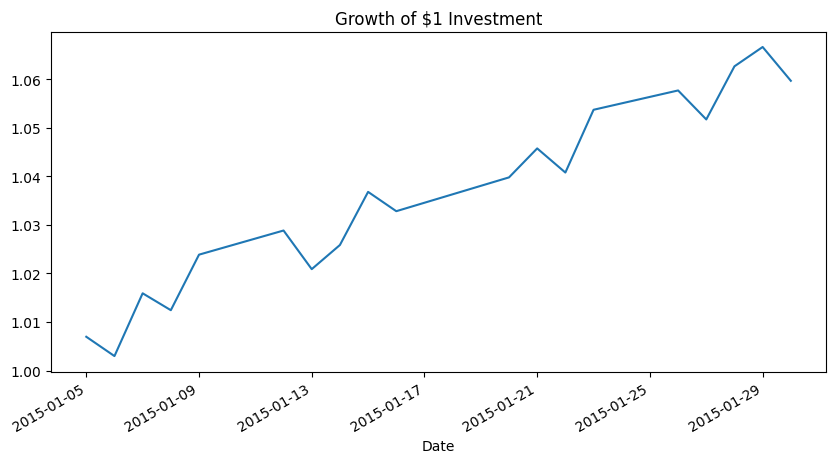

In [95]:
cumulative = (1 + returns).cumprod()

cumulative.plot(figsize=(10,5), title="Growth of $1 Investment")
plt.show()

In [97]:
total_return = cumulative.iloc[-1] - 1
years = 10

annual_return = (1 + total_return)**(1/years) - 1
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annual_return:.2%}")

Total Return: 5.97%
Annualized Return: 0.58%


In [99]:
annual_vol = returns.std() * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol:.2%}")

Annualized Volatility: 11.18%


In [101]:
risk_free = 0.02

sharpe = (annual_return - risk_free) / annual_vol
print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: -0.13


In [102]:
rolling_max = cumulative.cummax()
drawdown = (rolling_max - cumulative) / rolling_max

max_drawdown = drawdown.max()
print(f"Max Drawdown: {max_drawdown:.2%}")

Max Drawdown: 0.77%


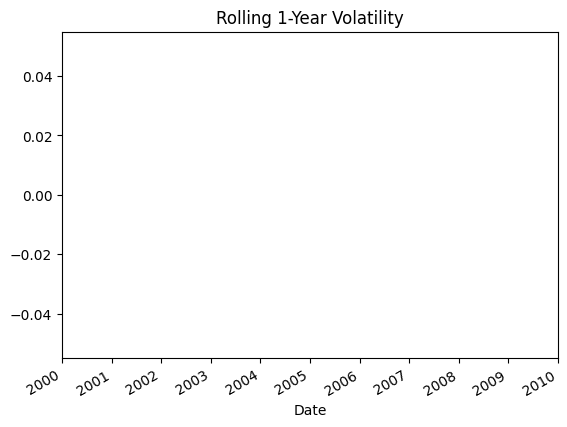

In [103]:
rolling_vol = returns.rolling(252).std() * np.sqrt(252)

rolling_vol.plot(title="Rolling 1-Year Volatility")
plt.show()


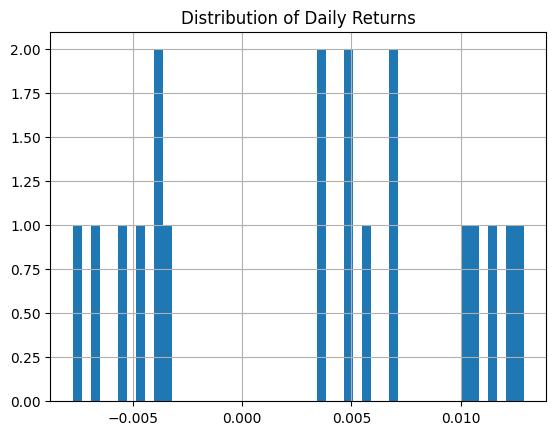

In [104]:
returns.hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.show()


In [105]:
returns.skew()
returns.kurtosis()


np.float64(-1.4727331857947683)

In [106]:
prices = pd.read_csv("multi_stock_10y.csv", index_col="Date", parse_dates=True)

returns = prices.pct_change().dropna()

correlation = returns.corr()
print(correlation)

FileNotFoundError: [Errno 2] No such file or directory: 'multi_stock_10y.csv'

In [107]:
summary = {
    "Total Return": total_return,
    "Annual Return": annual_return,
    "Annual Volatility": annual_vol,
    "Sharpe Ratio": sharpe,
    "Max Drawdown": max_drawdown
}

print(summary)


{'Total Return': np.float64(0.05970149253731272), 'Annual Return': np.float64(0.0058155709196878735), 'Annual Volatility': np.float64(0.11175797269111225), 'Sharpe Ratio': np.float64(-0.12692095909359824), 'Max Drawdown': np.float64(0.007736943907156684)}


In [108]:
FV = 10000
r = 0.08
n = 5

PV = FV / (1 + r)**n
PV


6805.831970337529

In [109]:
cash_flows = [2000, 3000, 4000, 5000]
r = 0.10

PV = sum(cf / (1 + r)**(t+1) for t, cf in enumerate(cash_flows))
PV


10717.847141588689

In [110]:
PMT = 1000
r = 0.05
n = 5

PV = PMT * (1 - (1 + r)**(-n)) / r
PV


4329.476670630823

In [112]:
PV = 10000
r = 0.08
n = 5

FV = PV * (1 + r)**n
FV


14693.280768000006

In [113]:
import numpy as np

PV = 10000
r = 0.08
t = 5

FV = PV * np.exp(r * t)
FV


np.float64(14918.246976412704)

In [114]:
PMT = 1000
r = 0.07
n = 10

FV = PMT * ((1 + r)**n - 1) / r
FV


13816.44796127952

In [115]:
PMT = 1000
r = 0.06
n = 5

PV = PMT * (1 - (1 + r)**(-n)) / r
PV

4212.363785565717

In [116]:
PMT = 1000
r = 0.07
n = 10

FV = PMT * ((1 + r)**n - 1) / r
FV

13816.44796127952

In [ ]:
PV_due = PV * (1 + r)
FV_due = FV * (1 + r)

In [118]:
PV = 20000
r = 0.05
n = 5

PMT = (PV * r) / (1 - (1 + r)**(-n))
PMT


4619.495962565359

In [121]:
import numpy as np
import pandas as pd

def mortgage_simulator(principal, annual_rate, years, extra_payment=0):
    r = annual_rate / 12
    n = years * 12
    
    # Monthly payment
    pmt = principal * r / (1 - (1 + r) ** (-n))
    
    balance = principal
    data = []
    
    for month in range(1, n+1):
        interest = balance * r
        principal_payment = pmt - interest + extra_payment
        balance -= principal_payment
        
        if balance < 0:
            principal_payment += balance
            balance = 0
        
        data.append([month, pmt, interest, principal_payment, balance])
        
        if balance == 0:
            break
    
    columns = ["Month", "Payment", "Interest", "Principal", "Remaining Balance"]
    return pd.DataFrame(data, columns=columns)


In [123]:
df = mortgage_simulator(240000, 0.06, 30)
print(df.head())

   Month     Payment     Interest   Principal  Remaining Balance
0      1  1438.92126  1200.000000  238.921260      239761.078740
1      2  1438.92126  1198.805394  240.115867      239520.962873
2      3  1438.92126  1197.604814  241.316446      239279.646427
3      4  1438.92126  1196.398232  242.523028      239037.123399
4      5  1438.92126  1195.185617  243.735643      238793.387755


In [125]:
df_extra = mortgage_simulator(240000, 0.06, 30, extra_payment=300)
print(df_extra.head())

   Month     Payment     Interest   Principal  Remaining Balance
0      1  1438.92126  1200.000000  538.921260      239461.078740
1      2  1438.92126  1197.305394  541.615867      238919.462873
2      3  1438.92126  1194.597314  544.323946      238375.138927
3      4  1438.92126  1191.875695  547.045566      237828.093361
4      5  1438.92126  1189.140467  549.780794      237278.312568


In [126]:
import numpy as np

def bond_price(face, coupon_rate, ytm, maturity):
    C = face * coupon_rate
    cash_flows = [C] * maturity
    cash_flows[-1] += face
    discount_factors = [(1 + ytm)**t for t in range(1, maturity+1)]
    price = sum(cf / df for cf, df in zip(cash_flows, discount_factors))
    return price

def macaulay_duration(face, coupon_rate, ytm, maturity):
    C = face * coupon_rate
    cash_flows = [C] * maturity
    cash_flows[-1] += face
    price = bond_price(face, coupon_rate, ytm, maturity)
    weighted_times = sum(
        t * (cf / (1 + ytm)**t)
        for t, cf in enumerate(cash_flows, start=1)
    )
    return weighted_times / price

def modified_duration(face, coupon_rate, ytm, maturity):
    D = macaulay_duration(face, coupon_rate, ytm, maturity)
    return D / (1 + ytm)

def portfolio_valuation(bonds):
    values = []
    durations = []
    
    for bond in bonds:
        price = bond_price(**bond)
        mod_dur = modified_duration(**bond)
        
        values.append(price)
        durations.append(mod_dur)
    
    total_value = sum(values)
    weights = [v / total_value for v in values]
    portfolio_duration = sum(w * d for w, d in zip(weights, durations))
    
    return total_value, portfolio_duration

# Example usage
bonds = [
    {"face":1000, "coupon_rate":0.05, "ytm":0.04, "maturity":3},
    {"face":1000, "coupon_rate":0.06, "ytm":0.05, "maturity":7},
    {"face":1000, "coupon_rate":0.00, "ytm":0.06, "maturity":10}
]

value, duration = portfolio_valuation(bonds)

print("Portfolio Value:", round(value,2))
print("Portfolio Duration:", round(duration,2))


Portfolio Value: 2644.01
Portfolio Duration: 5.33


In [129]:
import yfinance as yf
import numpy as np
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
TICKERS = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOGL']
START_DATE = "2015-01-01"
RISK_FREE_RATE = 0.04
TRADING_DAYS = 252

# -----------------------------
# DOWNLOAD DATA
# -----------------------------
def load_data(tickers, start_date):
    df = yf.download(tickers, start=start_date, auto_adjust=False)

    # Handle multi-index columns safely
    if isinstance(df.columns, pd.MultiIndex):
        df = df['Adj Close']
    else:
        df = df[['Adj Close']]

    # Drop rows where all values are missing
    df = df.dropna(how='all')

    return df


# -----------------------------
# CLEAN DATA
# -----------------------------
def clean_data(df):
    # Forward fill (common in finance)
    df = df.ffill()

    # Drop remaining NaNs
    df = df.dropna()

    # Ensure sorted index
    df = df.sort_index()

    # Validation checks
    assert df.index.is_monotonic_increasing, "Dates are not sorted!"
    assert (df > 0).all().all(), "Prices must be positive!"

    return df


# -----------------------------
# COMPUTE RETURNS
# -----------------------------
def compute_returns(df):
    # Log returns (preferred in quant finance)
    returns = np.log(df / df.shift(1))
    return returns.dropna()


# -----------------------------
# METRICS
# -----------------------------
def compute_metrics(returns, risk_free_rate):
    mean_returns = returns.mean() * TRADING_DAYS
    volatility = returns.std() * np.sqrt(TRADING_DAYS)

    cov_matrix = returns.cov() * TRADING_DAYS
    correlation = returns.corr()

    sharpe_ratio = (mean_returns - risk_free_rate) / volatility

    return {
        "mean_returns": mean_returns,
        "volatility": volatility,
        "cov_matrix": cov_matrix,
        "correlation": correlation,
        "sharpe_ratio": sharpe_ratio
    }


# -----------------------------
# MAIN PIPELINE
# -----------------------------
def main():
    print("Downloading data...")
    data = load_data(TICKERS, START_DATE)

    print("Cleaning data...")
    data = clean_data(data)

    print("Computing returns...")
    returns = compute_returns(data)

    print("Computing metrics...")
    metrics = compute_metrics(returns, RISK_FREE_RATE)

    print("\n===== RESULTS =====\n")

    print("Annualized Returns:")
    print(metrics["mean_returns"], "\n")

    print("Volatility:")
    print(metrics["volatility"], "\n")

    print("Sharpe Ratio:")
    print(metrics["sharpe_ratio"], "\n")

    print("Correlation Matrix:")
    print(metrics["correlation"], "\n")

    return data, returns, metrics


if __name__ == "__main__":
    data, returns, metrics = main()

[*********************100%***********************]  5 of 5 completed

Cleaning data...
Computing returns...
Computing metrics...

===== RESULTS =====

Annualized Returns:
Ticker
AAPL     0.210337
AMZN     0.235765
GOOGL    0.220005
META     0.186013
NFLX     0.263067
dtype: float64 

Volatility:
Ticker
AAPL     0.287618
AMZN     0.327639
GOOGL    0.286702
META     0.378149
NFLX     0.432794
dtype: float64 

Sharpe Ratio:
Ticker
AAPL     0.592234
AMZN     0.597502
GOOGL    0.627846
META     0.386124
NFLX     0.515411
dtype: float64 

Correlation Matrix:
Ticker      AAPL      AMZN     GOOGL      META      NFLX
Ticker                                                  
AAPL    1.000000  0.551966  0.588557  0.515047  0.402405
AMZN    0.551966  1.000000  0.634242  0.593954  0.498425
GOOGL   0.588557  0.634242  1.000000  0.601552  0.425240
META    0.515047  0.593954  0.601552  1.000000  0.439306
NFLX    0.402405  0.498425  0.425240  0.439306  1.000000 



In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

In [130]:
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400536  72.460799  71.156697  71.409800  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [132]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

data = yf.download(tickers, start="2020-01-01", end="2024-01-01")["Adj Close"]
print(data.tail())

[*********************100%***********************]  5 of 5 completed


KeyError: 'Adj Close'

In [134]:
returns = data.pct_change().dropna()
print(returns.head())

Price          Close      High       Low      Open    Volume
Ticker          AAPL      AAPL      AAPL      AAPL      AAPL
Date                                                        
2020-01-03 -0.009722 -0.000067  0.004438  0.003072  0.080029
2020-01-06  0.007968 -0.002063 -0.012648 -0.011307 -0.190918
2020-01-07 -0.004703  0.003134  0.016157  0.020593 -0.080374
2020-01-08  0.016087  0.011765 -0.001075 -0.008938  0.213160
2020-01-09  0.021241  0.019675  0.030421  0.033921  0.287927


In [135]:
mu = returns.mean() * 252        # annualized return
Sigma = returns.cov() * 252      # annualized covariance
print("Expected Returns (Annualized):")
print(mu)

Expected Returns (Annualized):
Price   Ticker
Close   AAPL      0.299015
High    AAPL      0.284062
Low     AAPL      0.289583
Open    AAPL      0.304347
Volume  AAPL      9.097116
dtype: float64


In [136]:
weights = np.ones(len(mu)) / len(mu)

portfolio_return = np.dot(weights, mu)
portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
print(f"Portfolio Return: {portfolio_return:.2%}")
print(f"Portfolio Volatility: {portfolio_vol:.2%}")

Portfolio Return: 205.48%
Portfolio Volatility: 97.68%


In [ ]:
sp500 = yf.download("^GSPC", start="2020-01-01", end="2024-01-01")["Adj Close"]
sp_returns = sp500.pct_change().dropna()

portfolio_returns = returns.dot(weights)

beta = np.cov(portfolio_returns, sp_returns)[0][1] / np.var(sp_returns)
print(f"Portfolio Beta: {beta:.2f}")

[*********************100%***********************]  1 of 1 completed


KeyError: 'Adj Close'

[*********************100%***********************]  1 of 1 completed


KeyError: 'Adj Close'

<Axes: xlabel='Date'>

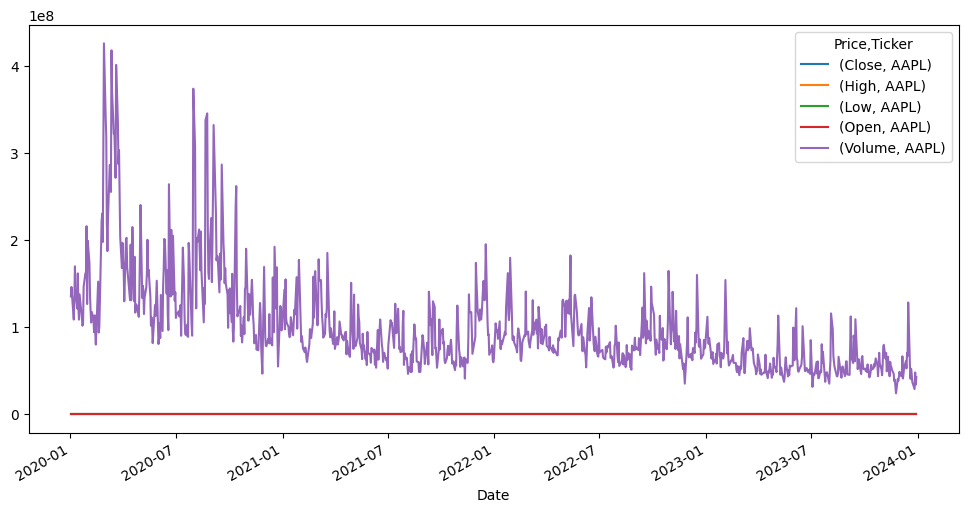

In [139]:
data.plot(figsize=(12,6))

In [142]:
import requests
import pandas as pd

API_KEY = "YOUR_API_KEY"

url = "https://www.alphavantage.co/query"

params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": "AAPL",
    "apikey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

print(data.keys())
time_series = data.get("Time Series (Daily)", {})
df = pd.DataFrame.from_dict(time_series, orient='index')

dict_keys(['Meta Data', 'Time Series (Daily)'])


In [143]:
prices = data["Time Series (Daily)"]

df = pd.DataFrame.from_dict(prices, orient="index")

df = df.astype(float)

df.index = pd.to_datetime(df.index)

print(df.head())

            1. open  2. high  3. low  4. close   5. volume
2026-03-17  252.955  255.130  252.18    254.23  32361607.0
2026-03-16  252.105  253.885  249.88    252.82  32074209.0
2026-03-13  255.480  256.330  249.52    250.12  36929988.0
2026-03-12  258.660  258.950  254.18    255.76  40794020.0
2026-03-11  261.090  262.130  259.55    260.81  26218927.0


In [146]:
df["returns"] = df["4. close"].pct_change()
print(df[["4. close", "returns"]].head())

            4. close   returns
2026-03-17    254.23       NaN
2026-03-16    252.82 -0.005546
2026-03-13    250.12 -0.010680
2026-03-12    255.76  0.022549
2026-03-11    260.81  0.019745


In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL"]

for ticker in tickers:
    params["symbol"] = ticker
    response = requests.get(url, params=params)
    data = response.json()


AAPL returns:


KeyError: '4. close'

In [151]:
params = {
    "function": "RSI",
    "symbol": "AAPL",
    "interval": "daily",
    "time_period": 14,
    "series_type": "close",
    "apikey": API_KEY
}
response = requests.get(url, params=params)
rsi_data = response.json()
print(rsi_data.keys())

dict_keys(['Meta Data', 'Technical Analysis: RSI'])


In [152]:
params = {
    "function": "FX_DAILY",
    "from_symbol": "EUR",
    "to_symbol": "USD",
    "apikey": API_KEY
}
response = requests.get(url, params=params)
fx_data = response.json()
print(fx_data.keys())

dict_keys(['Meta Data', 'Time Series FX (Daily)'])


In [153]:
params = {
    "function": "DIGITAL_CURRENCY_DAILY",
    "symbol": "BTC",
    "market": "USD",
    "apikey": API_KEY
}
response = requests.get(url, params=params)
crypto_data = response.json()
print(crypto_data.keys())

dict_keys(['Information'])


In [155]:
import requests

url = "https://hernandoabella.com"

response = requests.get(url)

html = response.text

print(html[:500])

<!DOCTYPE html><!--F_LgtmSeop8YcOUru_rPo--><html lang="en"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/><link rel="preload" href="/_next/static/media/c9bd7381a27f2960-s.p.efaf60a6.woff2" as="font" crossorigin="" type="font/woff2"/><link rel="preload" as="image" imageSrcSet="/_next/image?url=%2Fprofile.jpg&amp;w=640&amp;q=75 640w, /_next/image?url=%2Fprofile.jpg&amp;w=750&amp;q=75 750w, /_next/image?url=%2Fprofile.jpg&amp;w=828&amp;q=75 828w, /


In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")

print(soup.title.text)

SyntaxError: invalid syntax (796030137.py, line 11)

In [159]:
links = soup.find_all("a")

for link in links:
    print(link.get("href"))

https://portfolio-hernandoabella.vercel.app/
mailto:hernandoabella@gmail.com
https://twitter.com/hernandoabella
https://github.com/hernandoabella
https://www.linkedin.com/in/hernandoabella
https://www.youtube.com/c/hernandoabella
https://wa.me/+573043932597
https://www.instagram.com/hernandoabella
https://www.pinterest.com/hernandoabella
#contact
https://thevplan.com/
https://rentacontainerjj.com/
https://www.la-gir.com/
https://www.praxmedpublishing.com/
https://www.amazon.com/300-Python-Algorithms-Mastering-Problem-Solving-ebook/dp/B0DJFS471K
https://www.amazon.com/200-Python-Programs-Beginners/dp/B0CVLQTKHG
https://www.amazon.com/Python-Cheat-Sheet-Essentials-Mastering-ebook/dp/B0DK22TT6N
mailto:contact@hernandoabella.com
mailto:hernandoabella@gmail.com
https://calendly.com/hernandoabella/30min
https://twitter.com/hernandoabella
https://www.instagram.com/hernandoabella
https://www.youtube.com/c/hernandoabella
https://www.pinterest.com/hernandoabella
https://github.com/hernandoabella

In [160]:
paragraphs = soup.find_all("p")

for p in paragraphs:
    print(p.text)

I design and build high-performance web applications using modern stacks. Focusing on scalable code and exceptional user experiences.
Hey there! I'm Hernando, a Full-Stack Developer with over a decade of experience crafting high-performance web solutions.
Delivering high-performance digital products tailored to your specific business needs.
I transform Figma or Adobe XD designs into high-performance, responsive code.
High-converting landing pages built to turn visitors into customers with modern speed.
End-to-end web applications with robust backends and seamless user journeys.
Need a custom enterprise solution?Let's talk business
Click on any card to explore the live experience.
High-end corporate website focused on strategy and branding.
Industrial service website optimized for local SEO.
Institutional website with clean UI and performance build.
Professional Landing Page for publishing resources.
Navigation
Real feedback from readers mastering code with my collections.
"I picked up 

In [161]:
table = soup.find("table")

rows = table.find_all("tr")

for row in rows:
    cols = row.find_all("td")
    data = [col.text.strip() for col in cols]
    print(data)

AttributeError: 'NoneType' object has no attribute 'find_all'

In [ ]:
import pandas as pd

df = pd.DataFrame(data)


ValueError: If using all scalar values, you must pass an index

In [ ]:
from selenium import webdriver

driver = webdriver.Chrome()

driver.get("https://example.com")

html = driver.page_source

ModuleNotFoundError: No module named 'selenium'

In [ ]:
import time
time.sleep(2)

In [165]:
R_t = (P_t - P_{t-1}) / P_{t-1}

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3389610022.py, line 1)

In [166]:
import yfinance as yf
import pandas as pd

tickers = ["AAPL", "MSFT", "GOOGL"]

data = yf.download(
    tickers,
    period="1d",
    interval="1m"
)["Close"]
print(data.head())

[*********************100%***********************]  3 of 3 completed

Ticker                           AAPL       GOOGL        MSFT
Datetime                                                     
2026-03-18 13:30:00+00:00  252.020004  310.660004  395.679993
2026-03-18 13:31:00+00:00  252.889999  311.165009  395.744995
2026-03-18 13:32:00+00:00  253.399994  311.454987  396.100006
2026-03-18 13:33:00+00:00  253.774994  311.700012  397.140015
2026-03-18 13:34:00+00:00  253.860001  311.769989  396.983398


In [168]:
returns = data.pct_change()
print(returns.head())

Ticker                         AAPL     GOOGL      MSFT
Datetime                                               
2026-03-18 13:30:00+00:00       NaN       NaN       NaN
2026-03-18 13:31:00+00:00  0.003452  0.001626  0.000164
2026-03-18 13:32:00+00:00  0.002017  0.000932  0.000897
2026-03-18 13:33:00+00:00  0.001480  0.000787  0.002626
2026-03-18 13:34:00+00:00  0.000335  0.000225 -0.000394


In [169]:
weights = [0.4, 0.3, 0.3]

portfolio_returns = returns.dot(weights)

portfolio_value = (1 + portfolio_returns).cumprod()
print(portfolio_value.head())

Datetime
2026-03-18 13:30:00+00:00         NaN
2026-03-18 13:31:00+00:00    1.001918
2026-03-18 13:32:00+00:00    1.003276
2026-03-18 13:33:00+00:00    1.004897
2026-03-18 13:34:00+00:00    1.004980
dtype: float64


In [176]:
import pandas as pd

data = {
    "assets": 170,
    "liabilities": 90,
    "equity": 80,
    "current_assets": 70,
    "current_liabilities": 40
}

df = pd.DataFrame([data])

df["current_ratio"] = df["current_assets"] / df["current_liabilities"]
df["debt_to_equity"] = df["liabilities"] / df["equity"]

print(df)


   assets  liabilities  equity  current_assets  current_liabilities  \
0     170           90      80              70                   40   

   current_ratio  debt_to_equity  
0           1.75           1.125  


In [177]:
import pandas as pd

data = {
    "revenue": 100,
    "net_income": 15,
    "assets": 200,
    "equity": 80
}

df = pd.DataFrame([data])

df["profit_margin"] = df["net_income"] / df["revenue"]
df["roa"] = df["net_income"] / df["assets"]
df["roe"] = df["net_income"] / df["equity"]

print(df)

   revenue  net_income  assets  equity  profit_margin    roa     roe
0      100          15     200      80           0.15  0.075  0.1875


In [178]:
def revenue_growth(current, previous):
    return (current - previous) / previous

def cagr(final_value, initial_value, years):
    return (final_value / initial_value) ** (1 / years) - 1

rev_growth = revenue_growth(120, 100)
rev_cagr = cagr(200, 100, 5)

print("Revenue Growth:", round(rev_growth * 100, 2), "%")
print("CAGR:", round(rev_cagr * 100, 2), "%")


Revenue Growth: 20.0 %
CAGR: 14.87 %


NameError: name 'CF' is not defined

In [180]:
import yfinance as yf

def valuation_report(ticker):

    stock = yf.Ticker(ticker)
    info = stock.info

    price = info.get("currentPrice")
    eps = info.get("trailingEps")
    pe = info.get("trailingPE")
    revenue = info.get("totalRevenue")
    profit = info.get("netIncomeToCommon")

    estimated_price = eps * pe if eps and pe else None

    print("------ Company Valuation Report ------")
    print("Ticker:", ticker)
    print("Current Price:", price)
    print("EPS:", eps)
    print("P/E Ratio:", pe)
    print("Revenue:", revenue)
    print("Net Income:", profit)

    if estimated_price:
        print("Estimated Fair Price:", round(estimated_price, 2))

valuation_report("AAPL")


------ Company Valuation Report ------
Ticker: AAPL
Current Price: 248.96
EPS: 7.9
P/E Ratio: 31.513924
Revenue: 435617005568
Net Income: 117776998400
Estimated Fair Price: 248.96


In [ ]:
import yfinance as yf
import pandas as pd

# Fetch historical data
ticker = "AAPL"
data = yf.download(ticker, period="6mo", interval="1d")

# Simple Moving Average (20-day)
data['SMA20'] = data['Close'].rolling(window=20).mean()

# Exponential Moving Average (20-day)
data['EMA20'] = data['Close'].ewm(span=20, adjust=False).mean()

print(data[['Close', 'SMA20', 'EMA20']].tail())

[*********************100%***********************]  1 of 1 completed

Price            Close       SMA20       EMA20
Ticker            AAPL                        
Date                                          
2026-03-13  250.119995  262.749499  261.650940
2026-03-16  252.820007  262.601499  260.809899
2026-03-17  254.229996  262.118999  260.183241
2026-03-18  249.940002  261.398499  259.207695
2026-03-19  248.960007  260.817500  258.231724


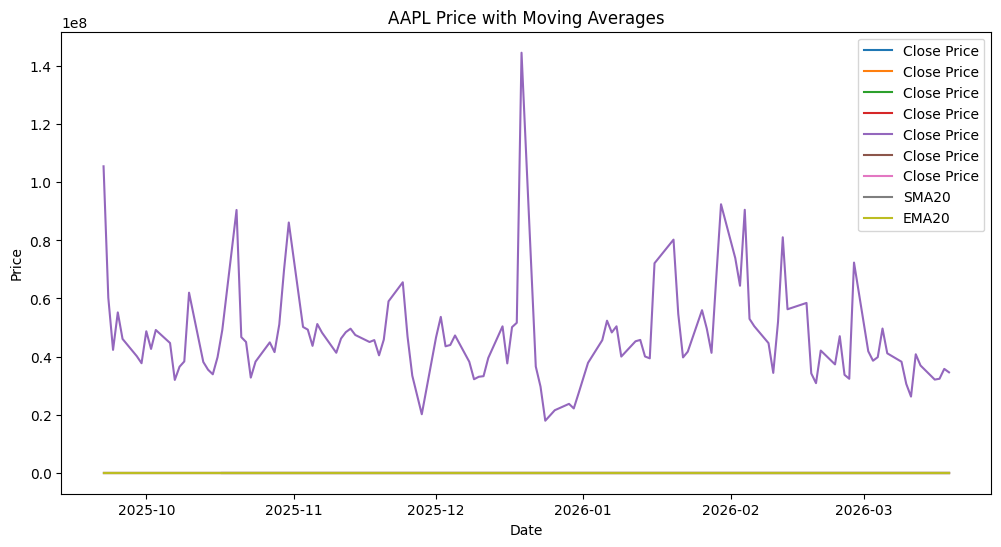

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data, label='Close Price')
plt.plot(data.index, data['SMA20'], label='SMA20')
plt.plot(data.index, data['EMA20'], label='EMA20')
plt.title(f"{ticker} Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [184]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download data
data = yf.download("AAPL", period="6mo", interval="1d")

# Calculate price changes
delta = data["Close"].diff()

# Separate gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Calculate average gain and loss (14-period)
window = 14
avg_gain = gain.rolling(window).mean()
avg_loss = loss.rolling(window).mean()

# Compute RS and RSI
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

data["RSI"] = rsi

print(data[["Close", "RSI"]].tail())


[*********************100%***********************]  1 of 1 completed

Price            Close        RSI
Ticker            AAPL           
Date                             
2026-03-13  250.119995  29.914981
2026-03-16  252.820007  23.692823
2026-03-17  254.229996  22.253049
2026-03-18  249.940002  20.537773
2026-03-19  248.960007  25.655808


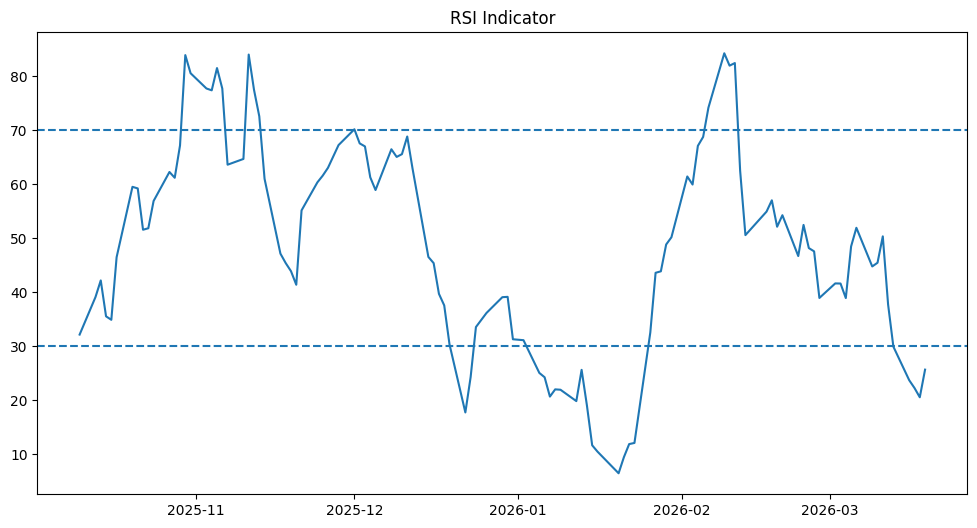

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data["RSI"])
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("RSI Indicator")
plt.show()


In [186]:
import yfinance as yf
import pandas as pd

# Download historical data
data = yf.download("AAPL", period="6mo", interval="1d")
close = data["Close"]

# Calculate EMAs
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# MACD line
macd = ema12 - ema26

# Signal line
signal = macd.ewm(span=9, adjust=False).mean()

# MACD histogram
histogram = macd - signal

# Add to dataframe
data["MACD"] = macd
data["Signal"] = signal
data["Histogram"] = histogram

print(data.tail())


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2026-03-13  250.119995  256.329987  249.520004  255.479996  36930000   
2026-03-16  252.820007  253.889999  249.880005  252.110001  32074200   
2026-03-17  254.229996  255.130005  252.179993  252.960007  32361600   
2026-03-18  249.940002  254.940002  249.000000  252.630005  35757900   
2026-03-19  248.960007  251.830002  247.300003  249.399994  34568663   

Price           MACD    Signal Histogram  
Ticker                                    
Date                                      
2026-03-13 -2.572495 -1.111666 -1.460830  
2026-03-16 -2.939636 -1.477260 -1.462376  
2026-03-17 -3.081305 -1.798069 -1.283236  
2026-03-18 -3.499405 -2.138336 -1.361069  
2026-03-19 -3.865274 -2.483724 -1.381550  


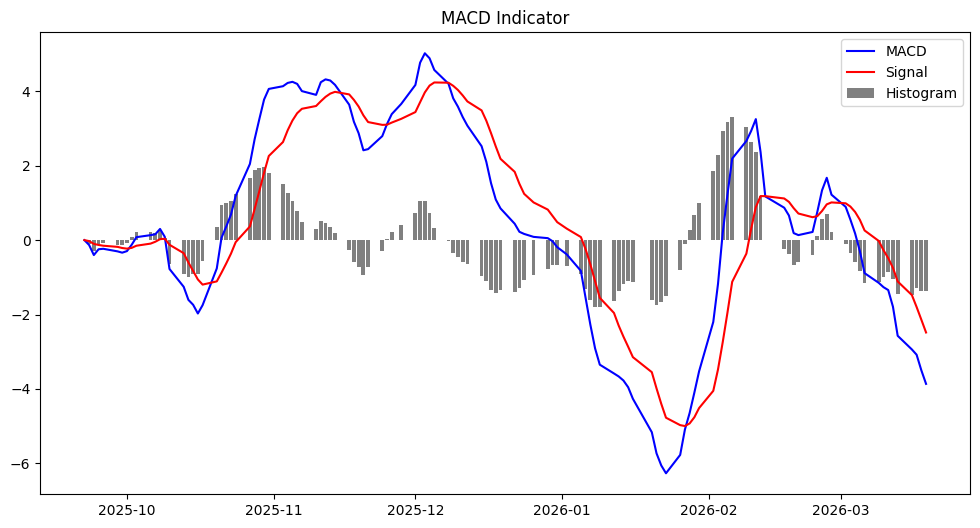

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data["MACD"], label="MACD", color="blue")
plt.plot(data.index, data["Signal"], label="Signal", color="red")
plt.bar(data.index, data["Histogram"], label="Histogram", color="grey")
plt.title("MACD Indicator")
plt.legend()
plt.show()


In [188]:
import yfinance as yf
import pandas as pd

# Download historical data
data = yf.download("AAPL", period="6mo", interval="1d")
close = data["Close"]

# Parameters
n = 20  # SMA period
k = 2   # Standard deviation multiplier

# Middle Band
data["SMA20"] = close.rolling(n).mean()

# Standard deviation
data["STD20"] = close.rolling(n).std()

# Upper and Lower Bands
data["Upper"] = data["SMA20"] + k * data["STD20"]
data["Lower"] = data["SMA20"] - k * data["STD20"]

print(data.tail())


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2026-03-13  250.119995  256.329987  249.520004  255.479996  36930000   
2026-03-16  252.820007  253.889999  249.880005  252.110001  32074200   
2026-03-17  254.229996  255.130005  252.179993  252.960007  32361600   
2026-03-18  249.940002  254.940002  249.000000  252.630005  35757900   
2026-03-19  248.960007  251.830002  247.300003  249.399994  34568663   

Price            SMA20     STD20       Upper       Lower  
Ticker                                                    
Date                                                      
2026-03-13  262.749499  5.899698  274.548895  250.950102  
2026-03-16  262.601499  6.116867  274.835233  250.367765  
2026-03-17  262.118999  6.385413  274.889825  249.348173  
2026-03-18  261.398499  6.911716  275.221931  247.575066  
2026-03-19

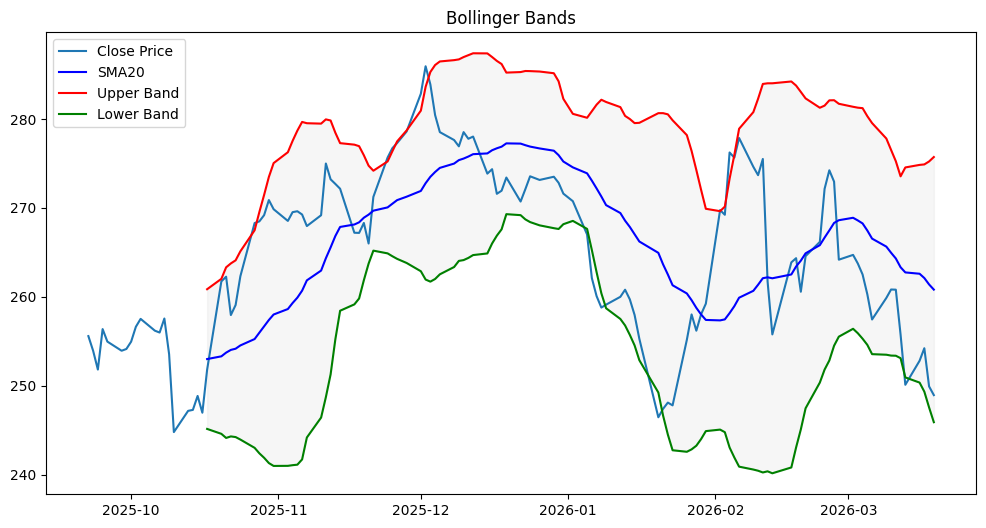

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], label="Close Price")
plt.plot(data.index, data["SMA20"], label="SMA20", color="blue")
plt.plot(data.index, data["Upper"], label="Upper Band", color="red")
plt.plot(data.index, data["Lower"], label="Lower Band", color="green")
plt.fill_between(data.index, data["Lower"], data["Upper"], color='lightgrey', alpha=0.2)
plt.title("Bollinger Bands")
plt.legend()
plt.show()

In [192]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

data = yf.download(tickers, period="2y")["Close"]

momentum = data.pct_change(126)  # ~6 months (252/2)

latest_momentum = momentum.iloc[-1]

top_assets = latest_momentum.sort_values(ascending=False).head(2)

print("Top Momentum Assets:")
print(top_assets)

selected = top_assets.index

weights = np.zeros(len(tickers))
for i, ticker in enumerate(tickers):
    if ticker in selected:
        weights[i] = 1 / len(selected)

portfolio_returns = data.pct_change().dot(weights)
cumulative_returns = (1 + portfolio_returns).cumprod()



[*********************100%***********************]  5 of 5 completed

Top Momentum Assets:
Ticker
GOOGL    0.232506
AAPL     0.043703
Name: 2026-03-19 00:00:00, dtype: float64


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

data = yf.download("AAPL", period="3y")["Close"]

short_ma = data.rolling(50).mean()
long_ma = data.rolling(200).mean()

# Signal: 1 when short MA > long MA
signal = np.where(short_ma > long_ma, 1, 0)

returns = data.pct_change()

strategy_returns = returns * signal

cumulative_market = (1 + returns).cumprod()
cumulative_strategy = (1 + strategy_returns).cumprod()

print("Total Strategy Return:",
      cumulative_strategy.iloc[-1] - 1)


[*********************100%***********************]  1 of 1 completed

Total Strategy Return: Ticker
AAPL   -0.127453
Name: 2026-03-19 00:00:00, dtype: float64


In [194]:
import numpy as np

# strategy_returns is a pandas Series

total_return = (1 + strategy_returns).prod() - 1

annual_return = (1 + total_return) ** (252/len(strategy_returns)) - 1

volatility = strategy_returns.std() * np.sqrt(252)

risk_free = 0.04
sharpe = (annual_return - risk_free) / volatility

# Maximum Drawdown
cumulative = (1 + strategy_returns).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative / peak) - 1
max_drawdown = drawdown.min()

print("Total Return:", total_return)
print("Annual Return:", annual_return)
print("Volatility:", volatility)
print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_drawdown)


Total Return: Ticker
AAPL   -0.127453
dtype: float64
Annual Return: Ticker
AAPL   -0.044602
dtype: float64
Volatility: Ticker
AAPL    0.172327
dtype: float64
Sharpe Ratio: Ticker
AAPL   -0.490939
dtype: float64
Max Drawdown: Ticker
AAPL   -0.271921
dtype: float64


In [195]:
import yfinance as yf
import pandas as pd

# Download historical data
data = yf.download("AAPL", period="3y")["Close"]

# Compute daily returns
returns = data.pct_change()

# Compute cumulative returns
cumulative = (1 + returns).cumprod()

# Compute rolling peak
peak = cumulative.cummax()

# Drawdown
drawdown = (cumulative / peak) - 1

# Maximum Drawdown
max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)


[*********************100%***********************]  1 of 1 completed

Maximum Drawdown: Ticker
AAPL   -0.333605
dtype: float64


ValueError: 'y1' is not 1-dimensional

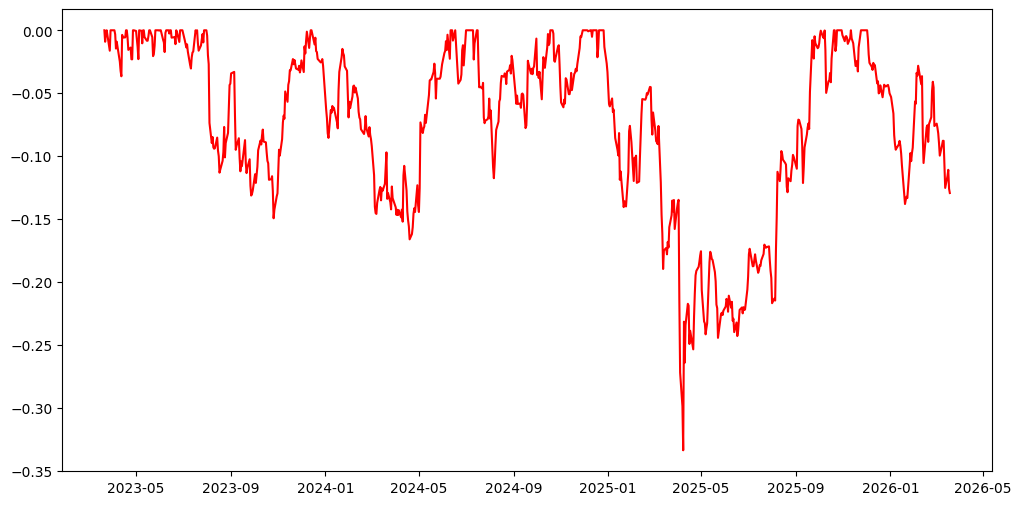

In [199]:
plt.figure(figsize=(12,6))

plt.plot(drawdown.index, drawdown, label="Drawdown", color="red")
plt.fill_between(drawdown.index, drawdown, 0, alpha=0.3)

plt.title("Drawdown Over Time")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

[*********************100%***********************]  1 of 1 completed


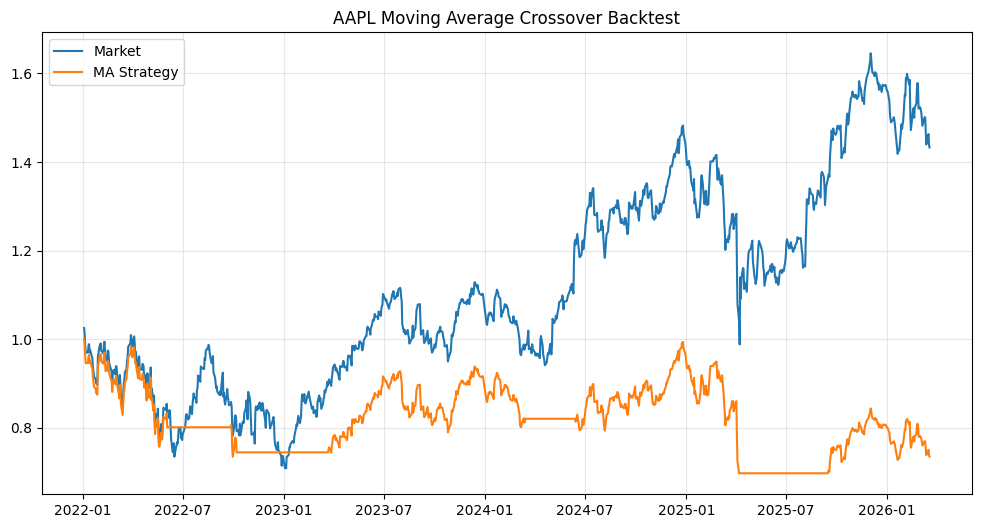


===== PERFORMANCE =====
Total Return: -26.56%
Annual Return: -7.10%
Volatility: 20.55%
Sharpe Ratio: -0.44


In [211]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# STEP 1 — DOWNLOAD DATA
# -----------------------------
ticker = "AAPL"
data = yf.download(ticker, period="5y")

# Keep only Close
data = data[['Close']].copy()

# -----------------------------
# STEP 2 — MOVING AVERAGES
# -----------------------------
short_window = 50
long_window = 200

data['SMA50'] = data['Close'].rolling(window=short_window).mean()
data['SMA200'] = data['Close'].rolling(window=long_window).mean()

# -----------------------------
# STEP 3 — SIGNALS (FIXED)
# -----------------------------
data['Signal'] = 0

# Use .loc to avoid warnings and bugs
data.loc[data.index[short_window:], 'Signal'] = np.where(
    data['SMA50'][short_window:] > data['SMA200'][short_window:],
    1,
    0
)

# Avoid look-ahead bias
data['Position'] = data['Signal'].shift(1)

# -----------------------------
# STEP 4 — RETURNS
# -----------------------------
data['Returns'] = data['Close'].pct_change()

# Strategy returns
data['Strategy'] = data['Returns'] * data['Position']

# Remove NaNs BEFORE cumulative calc (IMPORTANT)
data = data.dropna()

# -----------------------------
# CUMULATIVE RETURNS
# -----------------------------
data['CumulativeMarket'] = (1 + data['Returns']).cumprod()
data['CumulativeStrategy'] = (1 + data['Strategy']).cumprod()

# -----------------------------
# STEP 5 — VISUALIZATION
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(data.index, data['CumulativeMarket'], label='Market')
plt.plot(data.index, data['CumulativeStrategy'], label='MA Strategy')

plt.title(f'{ticker} Moving Average Crossover Backtest')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# -----------------------------
# STEP 6 — PERFORMANCE METRICS
# -----------------------------
total_return = data['CumulativeStrategy'].iloc[-1] - 1

# Annualized return
annual_return = (data['CumulativeStrategy'].iloc[-1]) ** (252 / len(data)) - 1

# Volatility
volatility = data['Strategy'].std() * np.sqrt(252)

# Sharpe Ratio (with risk-free rate)
risk_free_rate = 0.02
sharpe_ratio = (annual_return - risk_free_rate) / volatility

# -----------------------------
# OUTPUT
# -----------------------------
print("\n===== PERFORMANCE =====")
print(f"Total Return: {total_return:.2%}")
print(f"Annual Return: {annual_return:.2%}")
print(f"Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

In [212]:
cumulative = data['CumulativeStrategy']
peak = cumulative.cummax()
drawdown = (cumulative / peak) - 1
max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: -0.30305521647082456


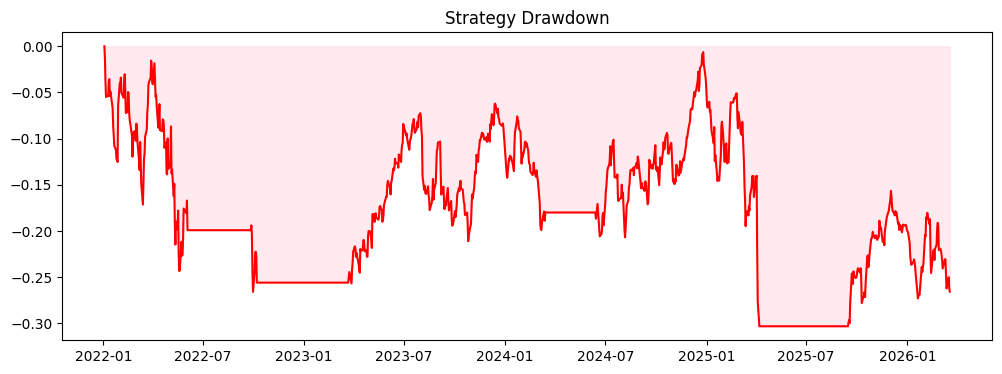

In [213]:
plt.figure(figsize=(12,4))
plt.plot(drawdown, color='red')
plt.fill_between(drawdown.index, drawdown, 0, color='pink', alpha=0.3)
plt.title('Strategy Drawdown')
plt.show()


In [ ]:
def execute_trade(api, symbol, side, quantity):
    
    # Basic validation
    if quantity <= 0:
        print("Invalid quantity")
        return
    
    # Submit market order
    order = api.submit_order(
        symbol=symbol,
        qty=quantity,
        side=side,
        type="market",
        time_in_force="day"
    )
    
    return order


In [215]:
MAX_POSITION_VALUE = 0.1  # 10% of portfolio

def safe_execute(api, symbol, side, price, equity):
    
    max_value = equity * MAX_POSITION_VALUE
    quantity = int(max_value / price)
    
    if quantity > 0:
        return execute_trade(api, symbol, side, quantity)


In [ ]:
try:
    order = api.submit_order(...)
except Exception as e:
    print("Order failed:", e)


In [216]:
def log_trade(symbol, side, quantity, price):
    logging.info(
        f"Trade executed: {side} {quantity} {symbol} at {price}"
    )


In [217]:
def system_health_check(api):
    try:
        account = api.get_account()
        logging.info("Connection OK")
    except Exception as e:
        logging.error(f"Connection failed: {e}")


In [ ]:
import time

while True:
    # Update data
    data = yf.download("AAPL", period="6mo")["Close"]
    
    # Recalculate signals
    short_ma = data.rolling(20).mean()
    long_ma = data.rolling(50).mean()
    
    if short_ma.iloc[-1] > long_ma.iloc[-1]:
        print("Buy signal detected")
    
    time.sleep(60)


In [218]:
import numpy as np

def call_payoff(S, K):
    return np.maximum(S - K, 0)

def put_payoff(S, K):
    return np.maximum(K - S, 0)

# Example
prices = np.linspace(50, 150, 100)

call = call_payoff(prices, 100)
put = put_payoff(prices, 100)


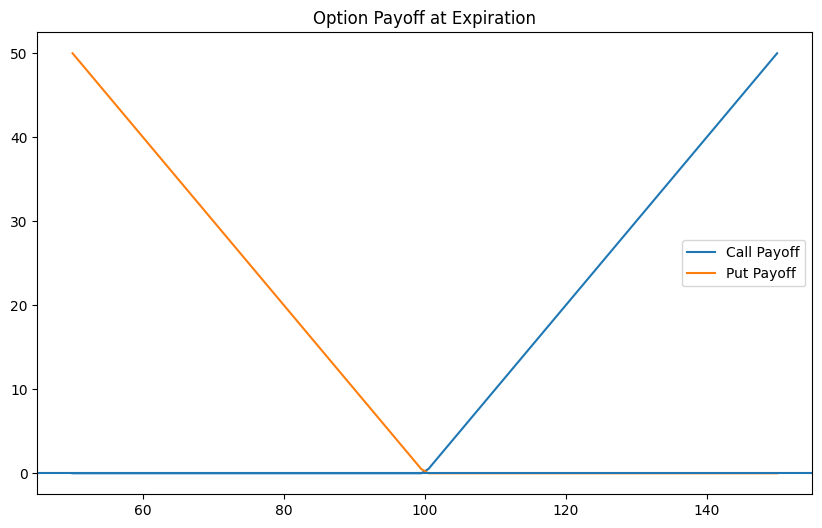

In [219]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(prices, call, label="Call Payoff")
plt.plot(prices, put, label="Put Payoff")
plt.axhline(0)
plt.legend()
plt.title("Option Payoff at Expiration")
plt.show()


In [220]:
import numpy as np
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    call_price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return call_price

# Example parameters
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

price = black_scholes_call(S, K, T, r, sigma)
print("Call Price:", price)


Call Price: 10.450583572185565


In [221]:
import numpy as np
from scipy.stats import norm

def black_scholes_greeks(S, K, T, r, sigma):
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = (-S * norm.pdf(d1) * sigma / (2*np.sqrt(T))
             - r*K*np.exp(-r*T)*norm.cdf(d2))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    
    return delta, gamma, theta, vega

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
delta, gamma, theta, vega = black_scholes_greeks(S, K, T, r, sigma)

print("Delta:", delta)
print("Gamma:", gamma)
print("Theta:", theta)
print("Vega:", vega)


Delta: 0.6368306511756191
Gamma: 0.018762017345846895
Theta: -6.414027546438197
Vega: 37.52403469169379


In [222]:
import numpy as np

def monte_carlo_call(S0, K, T, r, sigma, simulations=100000):
    
    # Simulate random normal values
    Z = np.random.standard_normal(simulations)
    
    # Simulate terminal stock prices
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    # Calculate payoff
    payoff = np.maximum(ST - K, 0)
    
    # Discount average payoff
    price = np.exp(-r*T) * np.mean(payoff)
    
    return price

# Example
price = monte_carlo_call(100, 100, 1, 0.05, 0.2)
print("Call Price:", price)


Call Price: 10.491779637605582


In [224]:
import numpy as np
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type="call"):
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
call_price = black_scholes(S, K, T, r, sigma, option_type="call")
put_price = black_scholes(S, K, T, r, sigma, option_type="put")
print("Call Price:", call_price)
print("Put Price:", put_price)  


Call Price: 10.450583572185565
Put Price: 5.573526022256971


In [225]:
def greeks(S, K, T, r, sigma):
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = (-S * norm.pdf(d1) * sigma / (2*np.sqrt(T))
             - r*K*np.exp(-r*T)*norm.cdf(d1 - sigma*np.sqrt(T)))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    
    return delta, gamma, theta, vega
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
delta, gamma, theta, vega = greeks(S, K, T, r, sigma)
print("Delta:", delta)
print("Gamma:", gamma)
print("Theta:", theta)  
print("Vega:", vega)


Delta: 0.6368306511756191
Gamma: 0.018762017345846895
Theta: -6.414027546438197
Vega: 37.52403469169379


In [226]:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

call_price = black_scholes(S, K, T, r, sigma, "call")
delta, gamma, theta, vega = greeks(S, K, T, r, sigma)

print("Call Price:", call_price)
print("Delta:", delta)
print("Gamma:", gamma)
print("Theta:", theta)
print("Vega:", vega)


Call Price: 10.450583572185565
Delta: 0.6368306511756191
Gamma: 0.018762017345846895
Theta: -6.414027546438197
Vega: 37.52403469169379


In [227]:
import numpy as np

random_uniform = np.random.rand(5)
print(random_uniform)

[0.07991002 0.69368654 0.83917769 0.12363801 0.42965117]


In [228]:
random_normal = np.random.randn(5)
print(random_normal)


[ 0.61298742  1.03628658 -1.5712256   0.15641344 -1.41432714]


In [229]:
import numpy as np

S0 = 100
r = 0.05
sigma = 0.2
T = 1

Z = np.random.randn(10000)

ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

print("Simulated Mean Price:", np.mean(ST))


Simulated Mean Price: 105.08064654274723


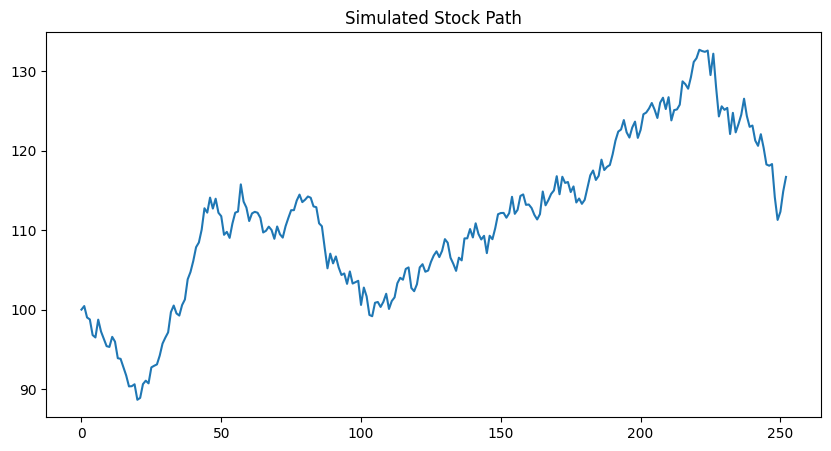

In [230]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100
r = 0.05
sigma = 0.2
T = 1
steps = 252
dt = T / steps

# Simulate one path
prices = [S0]

for _ in range(steps):
    Z = np.random.randn()
    S_next = prices[-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    prices.append(S_next)

# Plot
plt.figure(figsize=(10,5))
plt.plot(prices)
plt.title("Simulated Stock Path")
plt.show()


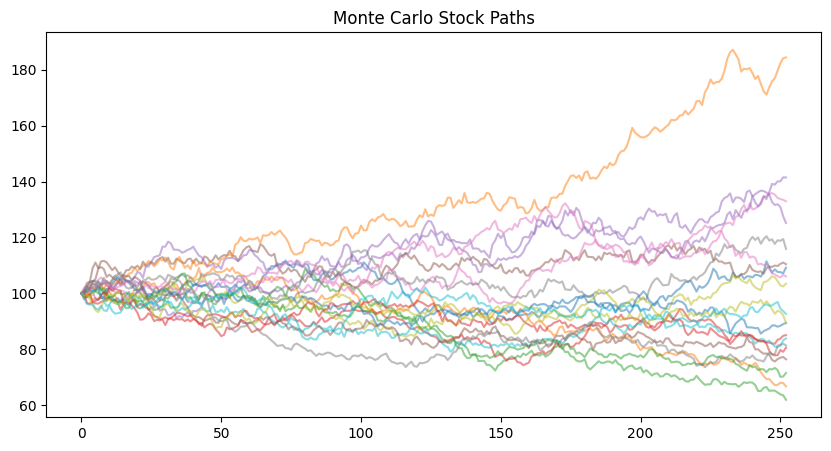

In [231]:
# Parameters
num_paths = 1000

paths = np.zeros((steps + 1, num_paths))
paths[0] = S0

for t in range(1, steps + 1):
    Z = np.random.randn(num_paths)
    paths[t] = paths[t-1] * np.exp(
        (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    )

# Plot sample paths
plt.figure(figsize=(10,5))
for i in range(20):
    plt.plot(paths[:, i], alpha=0.5)

plt.title("Monte Carlo Stock Paths")
plt.show()


In [232]:
import numpy as np
import yfinance as yf

# Get returns
data = yf.download("AAPL", period="1y")["Close"]
returns = data.pct_change().dropna()

# 95% Historical VaR
confidence = 0.95
var_95 = np.percentile(returns, (1 - confidence) * 100)

print("95% Daily VaR:", var_95)


[*********************100%***********************]  1 of 1 completed

95% Daily VaR: -0.030851420106301916


In [233]:
mean = returns.mean()
std = returns.std()

simulations = 10000
simulated_returns = np.random.normal(mean, std, simulations)

var_95_mc = np.percentile(simulated_returns, 5)

print("Monte Carlo 95% VaR:", var_95_mc)


Monte Carlo 95% VaR: -0.03211604995258547


In [234]:
import numpy as np

# Portfolio value
portfolio_value = 1_000_000

# Scenario: Market drops 15%
market_shock = -0.15

loss = portfolio_value * market_shock

print("Scenario Loss:", loss)


Scenario Loss: -150000.0


In [235]:
import numpy as np

# Weights
weights = np.array([0.4, 0.3, 0.3])

# Scenario returns (shock vector)
scenario_returns = np.array([-0.2, -0.1, -0.05])

portfolio_return = np.dot(weights, scenario_returns)

print("Portfolio Scenario Return:", portfolio_return)


Portfolio Scenario Return: -0.125


In [250]:
import numpy as np

mu = 0.0005       # daily mean return
sigma = 0.02       # daily volatility
simulations = 10000

simulated_returns = np.random.normal(mu, sigma, simulations)

confidence = 0.95

# VaR = 5th percentile of returns (losses)
var_95 = np.percentile(simulated_returns, (1 - confidence) * 100)

print("95% VaR:", var_95)

es_95 = simulated_returns[simulated_returns <= var_95].mean()

print("95% Expected Shortfall:", es_95)

initial_value = 1_000_000

simulated_values = initial_value * (1 + simulated_returns)

print("Average Portfolio Value:", simulated_values.mean())

# Create full price paths (NOT just single returns)
time_horizon = 252  # 1 year

paths = np.random.normal(mu, sigma, (simulations, time_horizon))

# Convert to price paths
price_paths = initial_value * np.cumprod(1 + paths, axis=1)

# Compute drawdowns
peak = np.maximum.accumulate(price_paths, axis=1)
drawdowns = price_paths / peak - 1

max_drawdown = drawdowns.min()

print("Worst Drawdown:", max_drawdown)

95% VaR: -0.03270748790082617
95% Expected Shortfall: -0.041130146886325464
Average Portfolio Value: 1000297.9994858614
Worst Drawdown: -0.7306886771219544


In [251]:
# Example: historical defaults
total_borrowers = 1000
defaults = 20

PD = defaults / total_borrowers
print("Probability of Default:", PD)


Probability of Default: 0.02


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

np.random.seed(42)

n_samples = 1000

# Features (borrower characteristics)
income = np.random.normal(50000, 15000, n_samples)
debt = np.random.normal(20000, 10000, n_samples)
credit_score = np.random.normal(650, 50, n_samples)

# Target: probability of default (synthetic rule)
prob_default = (
    (debt / income) * 0.5 +
    (700 - credit_score) * 0.003 +
    np.random.normal(0, 0.05, n_samples)
)

# Convert to binary (0 = no default, 1 = default)
y = (prob_default > 0.5).astype(int)

# Feature matrix
X = pd.DataFrame({
    "income": income,
    "debt": debt,
    "credit_score": credit_score
})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

PD_pred = model.predict_proba(X_test)[:, 1]

y_pred = (PD_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, PD_pred)

print("Accuracy:", accuracy)
print("AUC:", auc)

results = X_test.copy()
results["PD"] = PD_pred
results["Actual"] = y_test

print("\nSample Predictions:")
print(results.head())

Accuracy: 0.93
AUC: 0.978546626984127

Sample Predictions:
           income          debt  credit_score            PD  Actual
521  58150.402886  25820.977035    799.262950  5.113685e-08       0
737  64740.364759   9321.970784    667.116892  4.070111e-06       0
740  22386.886530  18955.507815    670.743275  1.948322e-01       0
660  41395.069897  33171.150673    591.220270  9.987772e-01       1
411  33130.368622  25562.300094    726.896596  2.546428e-03       0


In [254]:
import numpy as np
from scipy.stats import norm

V0 = 100       # Initial firm value
D = 80         # Debt at maturity
r = 0.05       # Risk-free rate
sigma = 0.2
T = 1
simulations = 100000

Z = np.random.randn(simulations)
VT = V0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
PD_mc = np.mean(VT < D)

print("Monte Carlo PD:", PD_mc)


Monte Carlo PD: 0.10308


In [255]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Example data (features: income, debt_ratio)
X = np.array([
    [50000, 0.2],
    [40000, 0.5],
    [60000, 0.1],
    [30000, 0.7]
])

# 0 = no default, 1 = default
y = np.array([0, 1, 0, 1])

# Train model
model = LogisticRegression()
model.fit(X, y)

# Predict probability of default
PD = model.predict_proba(X)[:,1]

print("Predicted PD:", PD)


Predicted PD: [2.98741453e-07 9.99999702e-01 2.65574303e-20 1.00000000e+00]


In [256]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Example dataset
# Features: income, debt_ratio
X = np.array([
    [50000, 0.2],
    [40000, 0.6],
    [60000, 0.1],
    [30000, 0.8]
])

# 0 = no default, 1 = default
y = np.array([0, 1, 0, 1])

model = LogisticRegression()
model.fit(X, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [258]:
PD = model.predict_proba(X)[:,1]
print("Probability of Default:", PD)

Probability of Default: [2.99424417e-07 9.99999692e-01 2.75906009e-20 1.00000000e+00]


In [261]:

A = 600
B = 20

score = A - B * np.log(PD / (1 - PD))
print("Credit Score:", score)

Credit Score: [ 900.42807034  300.11989349 1500.73623567          -inf]


C:\Users\pc\AppData\Local\Temp\ipykernel_22444\268396359.py:4: RuntimeWarning: divide by zero encountered in divide
  score = A - B * np.log(PD / (1 - PD))


In [ ]:
import pandas as pd

data = pd.DataFrame({
    "Income": [50000, 40000, 60000, 30000],
    "DebtRatio": [0.2, 0.6, 0.1, 0.8],
    "Age": [35, 42, 28, 50],
    "Default": [0, 1, 0, 1]
})

X = data[["Income", "DebtRatio", "Age"]]
y = data["Default"]

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

PD = model.predict_proba(X)[:,1]
data["PD"] = PD
print(data)



   Income  DebtRatio  Age  Default            PD
0   50000        0.2   35        0  2.984625e-07
1   40000        0.6   42        1  9.999997e-01
2   60000        0.1   28        0  2.954884e-20
3   30000        0.8   50        1  1.000000e+00


c:\Users\pc\anaconda3\envs\finance\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [265]:
import numpy as np

A = 600
B = 20
data["Score"] = A - B * np.log(data["PD"] / (1 - data["PD"]))
print(data)


   Income  DebtRatio  Age  Default            PD        Score
0   50000        0.2   35        0  2.984625e-07   900.492423
1   40000        0.6   42        1  9.999997e-01   301.620641
2   60000        0.1   28        0  2.954884e-20  1499.364847
3   30000        0.8   50        1  1.000000e+00         -inf


In [266]:
def risk_category(score):
    if score >= 650:
        return "Low Risk"
    elif score >= 600:
        return "Moderate Risk"
    else:
        return "High Risk"

data["Risk"] = data["Score"].apply(risk_category)
print(data)


   Income  DebtRatio  Age  Default            PD        Score       Risk
0   50000        0.2   35        0  2.984625e-07   900.492423   Low Risk
1   40000        0.6   42        1  9.999997e-01   301.620641  High Risk
2   60000        0.1   28        0  2.954884e-20  1499.364847   Low Risk
3   30000        0.8   50        1  1.000000e+00         -inf  High Risk


In [267]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y, PD)
print("AUC:", auc)


AUC: 1.0
